#FIND THE DATASET FILE

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/claytonmiller/buildingdatagenomeproject2/water_cleaned.csv
/kaggle/input/datasets/claytonmiller/buildingdatagenomeproject2/electricity_cleaned.csv
/kaggle/input/datasets/claytonmiller/buildingdatagenomeproject2/steam_cleaned.csv
/kaggle/input/datasets/claytonmiller/buildingdatagenomeproject2/water.csv
/kaggle/input/datasets/claytonmiller/buildingdatagenomeproject2/gas.csv
/kaggle/input/datasets/claytonmiller/buildingdatagenomeproject2/irrigation_cleaned.csv
/kaggle/input/datasets/claytonmiller/buildingdatagenomeproject2/weather.csv
/kaggle/input/datasets/claytonmiller/buildingdatagenomeproject2/hotwater_cleaned.csv
/kaggle/input/datasets/claytonmiller/buildingdatagenomeproject2/irrigation.csv
/kaggle/input/datasets/claytonmiller/buildingdatagenomeproject2/gas_cleaned.csv
/kaggle/input/datasets/claytonmiller/buildingdatagenomeproject2/chilledwater.csv
/kaggle/input/datasets/claytonmiller/buildingdatagenomeproject2/chilledwater_cleaned.csv
/kaggle/input/datasets/cl

#IMPORT LIBRARIES

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#LOAD THE DATA

In [7]:
building_cols = electricity.columns[1:11]  # first 10 buildings

electricity_small = electricity[
    ['timestamp'] + list(building_cols)
]

print(electricity_small.shape)

(17544, 11)


#MELTING

In [8]:
electricity_long = electricity_small.melt(
    id_vars='timestamp',
    var_name='building_name',
    value_name='electricity_usage'
)

print(electricity_long.shape)

(175440, 3)


In [9]:
electricity_long['timestamp'] = pd.to_datetime(
    electricity_long['timestamp']
)

weather['timestamp'] = pd.to_datetime(
    weather['timestamp']
)

#CHECK MISSING VALUES

In [10]:
print(electricity_long.isnull().sum())

timestamp                0
building_name            0
electricity_usage    34686
dtype: int64


#CONVERT TIMESTAMPS

In [11]:
electricity_long['timestamp'] = pd.to_datetime(
    electricity_long['timestamp']
)

weather['timestamp'] = pd.to_datetime(
    weather['timestamp']
)

#FEATURE ENGINEERING

In [12]:
electricity_long['hour'] = electricity_long['timestamp'].dt.hour
electricity_long['day'] = electricity_long['timestamp'].dt.day
electricity_long['month'] = electricity_long['timestamp'].dt.month
electricity_long['weekday'] = electricity_long['timestamp'].dt.weekday

In [13]:
metadata[['building_id','site_id']].head()

,building_id,site_id
0,Panther_lodging_Dean,Panther
1,Panther_lodging_Shelia,Panther
2,Panther_lodging_Ricky,Panther
3,Panther_education_Rosalie,Panther
4,Panther_education_Misty,Panther


In [14]:
electricity_long.head()

,timestamp,building_name,electricity_usage,hour,day,month,weekday
0,2016-01-01 00:00:00,Panther_parking_Lorriane,NaN,0,1,1,4
1,2016-01-01 01:00:00,Panther_parking_Lorriane,NaN,1,1,1,4
2,2016-01-01 02:00:00,Panther_parking_Lorriane,NaN,2,1,1,4
3,2016-01-01 03:00:00,Panther_parking_Lorriane,NaN,3,1,1,4
4,2016-01-01 04:00:00,Panther_parking_Lorriane,NaN,4,1,1,4


In [15]:
print("Total rows:", len(electricity_long))

print("Missing electricity values:",
      electricity_long['electricity_usage'].isna().sum())

print("Percentage missing:",
      100 * electricity_long['electricity_usage'].isna().mean())

Total rows: 175440
Missing electricity values: 34686
Percentage missing: 19.770861833105336


#MERGE METADATA

In [16]:
electricity_long = electricity_long.merge(
    metadata,
    left_on='building_name',
    right_on='building_id',
    how='left'
)

#VERIFY MERGE

In [17]:
electricity_long[['building_name',
                  'site_id',
                  'primaryspaceusage',
                  'sqft']].head()

,building_name,site_id,primaryspaceusage,sqft
0,Panther_parking_Lorriane,Panther,Parking,387638.0
1,Panther_parking_Lorriane,Panther,Parking,387638.0
2,Panther_parking_Lorriane,Panther,Parking,387638.0
3,Panther_parking_Lorriane,Panther,Parking,387638.0
4,Panther_parking_Lorriane,Panther,Parking,387638.0


#MERGE WEATHER

In [18]:
data = electricity_long.merge(
    weather,
    on=['timestamp', 'site_id'],
    how='left'
)

#REMOVE ROWS WHERE THE TARGET IS MISSING

In [19]:
data = data.dropna(subset=['electricity_usage'])

print(data.shape)

(140754, 47)


#CREATING TIME FEATURES

In [20]:
data['hour'] = data['timestamp'].dt.hour
data['day'] = data['timestamp'].dt.day
data['month'] = data['timestamp'].dt.month
data['weekday'] = data['timestamp'].dt.weekday

#CHECK MISSING VALUES

In [21]:
print(data.isnull().sum().sort_values(ascending=False).head(20))

solar              140754
heatingtype        140754
occupants          140754
rating             140754
source_eui         140754
energystarscore    140754
site_eui           140754
numberoffloors     140754
industry           140754
hotwater           140754
subindustry        140754
date_opened        140754
steam              140754
precipDepth6HR     135390
leed_level         126596
gas                 98284
chilledwater        98247
irrigation          98243
cloudCoverage       59220
water               27338
dtype: int64


#VERIFYING WEATHER COLUMN EXISTS

In [22]:
print(data.columns.tolist())

['timestamp', 'building_name', 'electricity_usage', 'hour', 'day', 'month', 'weekday', 'building_id', 'site_id', 'building_id_kaggle', 'site_id_kaggle', 'primaryspaceusage', 'sub_primaryspaceusage', 'sqm', 'sqft', 'lat', 'lng', 'timezone', 'electricity', 'hotwater', 'chilledwater', 'steam', 'water', 'irrigation', 'solar', 'gas', 'industry', 'subindustry', 'heatingtype', 'yearbuilt', 'date_opened', 'numberoffloors', 'occupants', 'energystarscore', 'eui', 'site_eui', 'source_eui', 'leed_level', 'rating', 'airTemperature', 'cloudCoverage', 'dewTemperature', 'precipDepth1HR', 'precipDepth6HR', 'seaLvlPressure', 'windDirection', 'windSpeed']


In [23]:
features = [
    'sqft',
    'airTemperature',
    'cloudCoverage',
    'dewTemperature',
    'windSpeed',
    'hour',
    'day',
    'month',
    'weekday'
]

In [24]:
for col in features:
    data[col] = data[col].fillna(data[col].median())

In [25]:
X = data[features]
y = data['electricity_usage']

#SPLIT

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

#TRAIN

In [27]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [28]:
print(X.shape)

(140754, 9)


In [30]:
preds = model.predict(X_test)
print(X_test.shape)

(28151, 9)


#TRAIN THE MODEL

In [31]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=50, n_jobs=-1, random_state=42)

In [32]:
preds = model.predict(X_test)

#EVALUATE

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 6.744222940754001
RMSE: 10.960419290640656
R²  : 0.993979900644018


#FEATURE IMPORTANCE

In [34]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

          Feature  Importance
0            sqft    0.966452
5            hour    0.014071
1  airTemperature    0.006411
3  dewTemperature    0.003011
8         weekday    0.002834
6             day    0.002811
7           month    0.002689
4       windSpeed    0.001374
2   cloudCoverage    0.000348


#PLOTTING

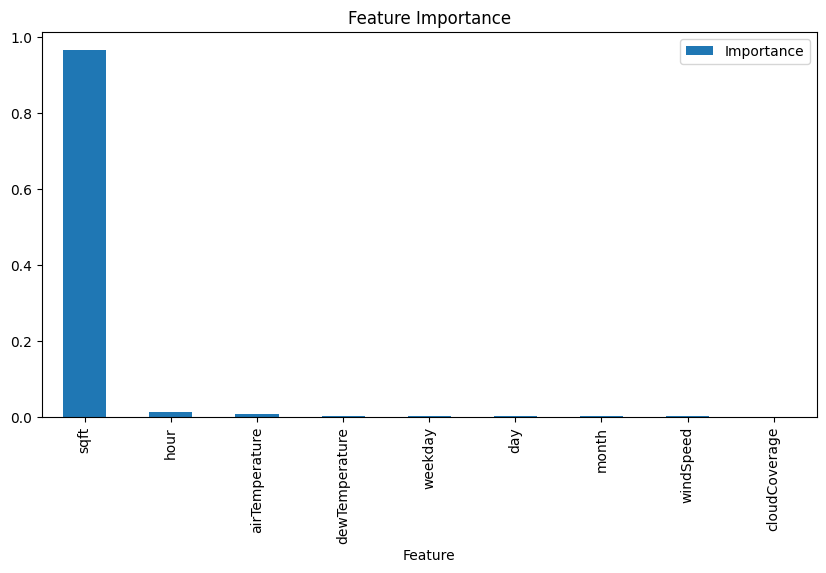

In [35]:
import matplotlib.pyplot as plt

importance.plot(
    x='Feature',
    y='Importance',
    kind='bar',
    figsize=(10,5)
)

plt.title("Feature Importance")
plt.show()

#ACTUAL VS PREDICTED

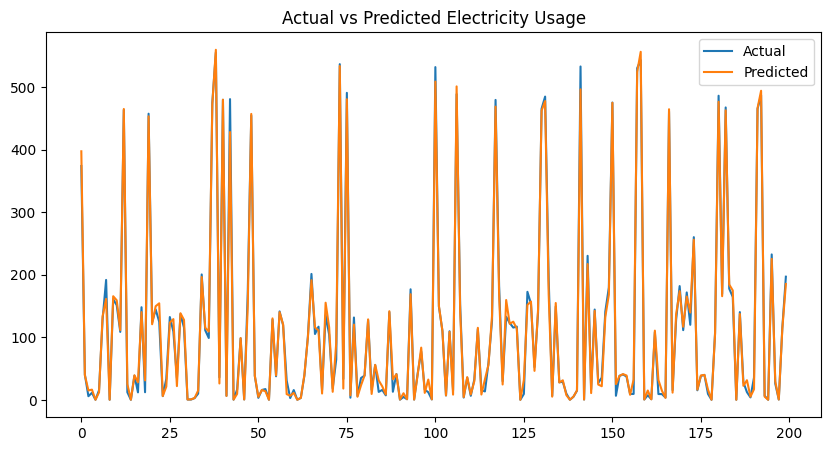

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values[:200], label='Actual')
plt.plot(preds[:200], label='Predicted')
plt.legend()
plt.title('Actual vs Predicted Electricity Usage')
plt.show()

In [40]:
git init
git add .
git commit -m "Initial commit"
git branch -M main

SyntaxError: invalid syntax (7524504.py, line 1)